In [320]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
myFmt = mdates.DateFormatter('%H:%M:%S') 
# Check https://strftime.org/ for formatters

In [321]:
#read chronos file
def time_reader(f, time_correction=False):
    f=open(f)
    lines = f.readlines()
    time_map = {} 
    #start datetime: {end datetime: e_dt, network latency per img: nw, 
    # compute latency per imd : comp, throughput: th, batch_size: bs, num_batches: nb, 
    # total_time: e_dt - start_dt, (apply day correction if required) 
    # network latency total: nw_t, compute latency total: comp_t, 
    # flop: fp, s_per_op: s*10**9/op, nw_std: 0, comp_std: 0 } 
    dt_st=0
    dt_et=0
    last_iter = 0
    last_rank=False
    for line in lines:
        line=line.strip()
        if "startheat" in line:
            st = line.split("TIME:")[-1]
            dt_st = datetime.strptime(st, "%H:%M:%S.%f")
        if "Gloo" in line:
            # [Gloo] Rank 1 is connected to 2 peer ranks. Expected number of connected peer ranks is : 2
            rank = line.split(" ")[2]
            world = line.split(" ")[-1]
            last_rank = (rank==world)

        if "FLOP count" in line:
            #this means it was successful (probably)
            #create dict object here
            # rank 0 FLOP count: 472055808 and full time*10**9 s/op: 0.3508
            flop = line.split("count: ")[-1].split(" and ")[0]
            s_per_op = line.split("s/op: ")[-1]
            time_map[dt_st] = {"e_dt":0, "nw":0, "comp":0, "th":0, "bs":0, "nb":0, "total_time":0, 
            "nw_t":0, "comp_t":0, "flop":int(flop), "s_per_op": float(s_per_op), "nw_std": 0, "comp_std": 0}
        elif "Time taken by rank:" in line:
            # Time taken by rank:0 in total(avg): 7.3928s 
            # Batch time sets raw:[[0.862, 0.9081, 0.8546, 0.8402, 0.8263, 0.8047, 0.8047]] 
            # Network sets raw:[[0, 0.0684, 0.4153, 0.4189, 0.4478, 0.4532, 0.4849]] -> first rank node
            # on avg per image: 0.3080s with std: 0.0000s network time: 0.3269s and 
            # network std: 0.1873s network time per img: 0.0136 compute time: 0.2944s 
            # compute/network ratio: 0.9005 and throughput 3.2464 img/s


            # Time taken by rank:1 in total(avg): 8.6006s 
            # Batch time sets raw:[[1.2193, 1.1692, 1.1837, 1.174, 1.1817, 1.1808, 1.1808]] 
            # Network sets raw:[[0.9594, 0.1024, 0.1042, 0.1018, 0.1043, 0.1055, 0.0017]] -> middle rank node
            # on avg per image: 0.3584s with std: 0.0000s network time: 0.2113s and 
            # network std: 0.3074s network time per img: 0.0088 compute time: 0.3496s 
            # compute/network ratio: 1.6541 and throughput 2.7905 img/s


            # Time taken by rank:2 in total(avg): 8.6231s 
            # Batch time sets raw:[[0.0122, 0.0122, 0.007, 0.0119, 0.01, 0.0114]] 
            # Network sets raw:[[2.1985, 1.2599, 1.2762, 1.2699, 1.2751, 1.2731]] 
            # on avg per image: 0.3593s with std: 0.0000s network time: 1.4254s and 
            # network std: 0.3457s network time per img: 0.0594 compute time: 0.2999s 
            # compute/network ratio: 0.2104 and throughput 2.7832 img/s


            nw_t = line.split("network time: ")[-1].split("s")[0]
            nw = line.split("network time per img: ")[-1].split("s")[0]
            nw_std = line.split("network std: ")[-1].split("s")[0]
            comp_t = line.split("total(avg): ")[-1].split("s")[0]
            comp = line.split("avg per image: ")[-1].split("s")[0]
            comp_std = line.split("with std: ")[-1].split("s")[0]
            th = line.split("throughput ")[-1].split(" ")[0]
            time_map[dt_st]["nw_t"] = nw_t
            time_map[dt_st]["nw"] =  nw
            time_map[dt_st]["nw_std"]=nw_std
            time_map[dt_st]["comp_t"] =comp_t
            time_map[dt_st]["comp"] = comp
            time_map[dt_st]["comp_std"]=comp_std
            time_map[dt_st]["th"]=th

            block_times = ast.literal_eval(line.split("Batch time sets raw:")[-1].split("] ")[0]+"]")[-1]
            net_times = ast.literal_eval(line.split("Network sets raw:")[-1].split("] ")[0]+"]")[-1]            
            #combine lists and then np.cumulative_sum to get the block boundaries
            #plot them against throttle points and heatmap maybe? 
            #start on network, end on network, if any remaining compute -> leave as is
            timing = []
            while True:
                net_p = net_times.pop(0)
                timing.append(net_p)
                if len(net_times) == 0:
                    break
                comp_p = block_times.pop(0)
                timing.append(comp_p)
            if last_rank: #corner case when rank=world, checks gloo message to verify last rank
                timing.append(block_times.pop(0))

               
            time_map[dt_st]["timing"] = np.cumulative_sum([it for it in timing])
            #even index on cumulative sum is network, odd index is compute        

        if "Sync done" in line:
            # 2026-03-17 13:59:28.033112 Sync done -> model run start
            last_iter = datetime.strptime(line.split(" ")[1].split(".")[0], "%H:%M:%S") #this is compared against heatfiles
        if "endheat" in line:
            et  = line.split("TIME:")[-1]
            if dt_st not in time_map:
                break
            dt_et = datetime.strptime(et, "%H:%M:%S.%f")
            time_map[dt_st]["e_dt"] = dt_et
    
    if dt_et==0 or dt_st==0:
        return None, None
    if time_correction:
        pass

         
    return time_map, last_iter

#read heat file
def heat_reader(f, last_iter=None, time_correction=False):
    f=open(f)
    lines=f.readlines()
    heat_map={}
    #{dt:{temp:t, volt:v, freq:f, throttled:t, total_volt: tv}}
    for l in range(len(lines)-2):
        line=lines[l]
        line=line.strip()
        # TIME:17:49:20
        # 32172
        # freq:frequency(48)=1400000000,throttle_flag:throttled=0x50000,voltage:volt=1.3500V,volt=1.2500V,volt=1.2500V,volt=1.2250V
        if "TIME:" in line:
            dt = datetime.strptime(line.split("TIME:")[-1], "%H:%M:%S")
            if last_iter!=None and dt < last_iter:
                continue
            temp_line = lines[l+1].strip()
            # print("here?")
            if "TIME" not in temp_line and "freq" not in temp_line:
                temp = float(temp_line)/10**3
                freq_line = lines[l+2]
                if "volt" in freq_line:
                    freq = float(freq_line.split(",")[0].split("=")[-1])*10**-9
                    throttled = (freq_line.split(",")[1].split("=")[-1][-1] == "0")
                    volts = [ float(v.split("volt=")[-1].split("V")[0]) for v in freq_line.split("voltage:")[-1].split(",")]
                    heat_map[dt]={"temp":temp, "volt":volts[0], "freq":freq, "throttled": throttled, "total_volt":sum(volts)}
                else:
                    continue

            else:
                continue
    if time_correction:
        pass

    return heat_map



def tf_calc(w):
    y=0
    if w < 8:
        y = 0.157 - 0.004*27 + 0.075*w
    else:
        y = 0.667 - 0.008*27 + 0.023*w
    return y

def cdf_gen(arr, e=False):
    sorted_arr = sorted(arr)
    y=[]
    for x in range(len(sorted_arr)):
        counter = len(sorted_arr[x+1:]) if e else x+1
        y.append(counter/len(sorted_arr))
    return sorted_arr, y 

        # for i in range(x, len(sorted_arr)):


#time sync/match chronos and heat file


In [322]:
failure = {}
world_size_count = 0
world_size_5_count = 0
world_size_5_fail_count = 0
num_batch_size_10_count = 0
num_batch_size_10_fail_count = 0
batch_size_6_count = 0
batch_size_6_fail_count = 0
total_counter=0
throttle_map={}
# machines = [[1,2],[1,3],[1,4],[2,4],[2,5],[2,6],[4,3]]
machines = [[2,5], [2,6], [4,3], [4,5]]
# machines = [[2,6], [4,3], [4,5]]

timing_plot=False
for m in machines:
    for mid in range(1,43): #device id in subcluster
        set_flag=False
        for world_size in [4,3,2,1]: #[4,2,1]: #number of layer splits/pipeline depth
            if timing_plot==True:
                fig, timing_axs = plt.subplots(figsize=(25,10))
                timing_axs.xaxis.set_major_formatter(myFmt)
            for batch_size in [4]: #[4,1]:#[1,4,6]:  #number of images in a batch per inference
                for num_batch in [10, 6]:#[5,3,1] :#[1,10]: #number of batches per exp
                    counter=0
                    # failures = 
                    #try to sweep all possible files:
                    for trial in range(1,43):
                        for rank in range(1,11):
                            # fname = f"../logs/snapshot_sweep/b-{m[0]}-{m[1]}/1_ranking_logs/{mid}_{world_size}_{batch_size}_{num_batch}_logs/" 
                            fname = f"../logs/trail_sweep/b-{m[0]}-{m[1]}/{rank}_ranking_logs/{mid}_{world_size}_{batch_size}_{num_batch}_logs/" 
                            # fname = f"../logs/trail_sweep/b-{m[0]}-{m[1]}/run/{mid}_{world_size}_{batch_size}_{num_batch}_logs/" 
                            # fname = f"../logs/archive_sweep/b-{m[0]}-{m[1]}/1_ranking_logs/{mid}_{world_size}_{batch_size}_{num_batch}_logs/" 
                            # fname = f"../logs/sweep/b-1-2/1_ranking_logs/{mid}_{world_size}_{batch_size}_{num_batch}_logs/" 
                            c_fname = f"{fname}/speed_chronosbramble-{m[0]}-{m[1]}-{trial}.log"
                            h_fname = f"{fname}/speed_heatbramble-{m[0]}-{m[1]}-{trial}.log"
                            if Path(c_fname).is_file() and Path(h_fname).is_file():
                                set_flag=True
                                # if m[0]==4 and m[1]==5:
                                #     print("check")
                                # print("check")
                                # print(mid, world_size, batch_size, num_batch)
                                time_map, last_iter = time_reader(c_fname)
                                total_counter+=1
                                # print(time_map!=None)
                                if world_size==5:
                                    world_size_5_count+=1
                                if num_batch==10:
                                    num_batch_size_10_count+=1
                                if batch_size==6:
                                    batch_size_6_count+=1
                                if time_map==None:
                                    failure[f"{m[0]}+{m[1]}+main_{mid}_{world_size}_{batch_size}_{num_batch}_worker_{trial}"] = (time_map==None)
                                    if world_size==5:
                                        world_size_5_fail_count+=1
                                    if num_batch==10:
                                        num_batch_size_10_fail_count+=1
                                    if batch_size==6:
                                        batch_size_6_fail_count+=1
                                counter+=1
                                if time_map!=None:
                                    #don't have to take average for fractional throttle
                                    heat_map = heat_reader(h_fname, last_iter=last_iter)

                                    
                                    #timing diagram time!
                                    last_time = 0
                                    for t_ind, t in enumerate(list(time_map.values())[0]["timing"]):
                                        i = last_iter + timedelta(seconds = t)
                                        last_time = i
                                        if timing_plot==True:
                                            if t_ind%2==0:
                                                timing_axs.axvline(x=i, ymin=0, ymax=1, color="blue")
                                            else:
                                                timing_axs.axvline(x=i, ymin=0, ymax=1, color="orange")
                                    #plot x and y 
                                    time_x = [ x for x in heat_map if x < last_time]
                                    time_y = [(1 if heat_map[x]["throttled"]==False else 0) for x in heat_map if x < last_time]
                                    if timing_plot==True:
                                        timing_axs.plot(time_x, time_y, label=f"{h_fname}", linestyle="--")
                                    
                                    k = f"{m[0]}+{m[1]}+main_{mid}_{world_size}_{batch_size}_{num_batch}_worker_{trial}"
                                    if k not in throttle_map:
                                        throttle_map[k] = {"total":0, 
                                    "throttled":0} 
                                    # else:
                                    # print(last_time)
                                    throttle_map[k]["total"]+=len(time_x)
                                    throttle_map[k]["throttled"]+=sum(time_y)

                                #for k in heat_map.keys():

                                    # if heat_map[k]["temp"] > 60:
                                    #     print("heat throttled?")
                                    # if heat_map[k]["throttled"]:
                                    #     print(heat_map[k]["volt"], heat_map[k]["total_volt"])
                                # print(heat_map)
                                # print(h_fname)
                                # break
                            if counter==world_size*10:
                                if timing_plot==True:
                                    timing_axs.legend()

                                break
                                # timing_axs.legend()
                                # raise("blah")
            #             break
            #         break
            #     break
            # break
        # if set_flag:
        #     break
# print(failure.keys())

#get actual physically observed overlaps with these devices





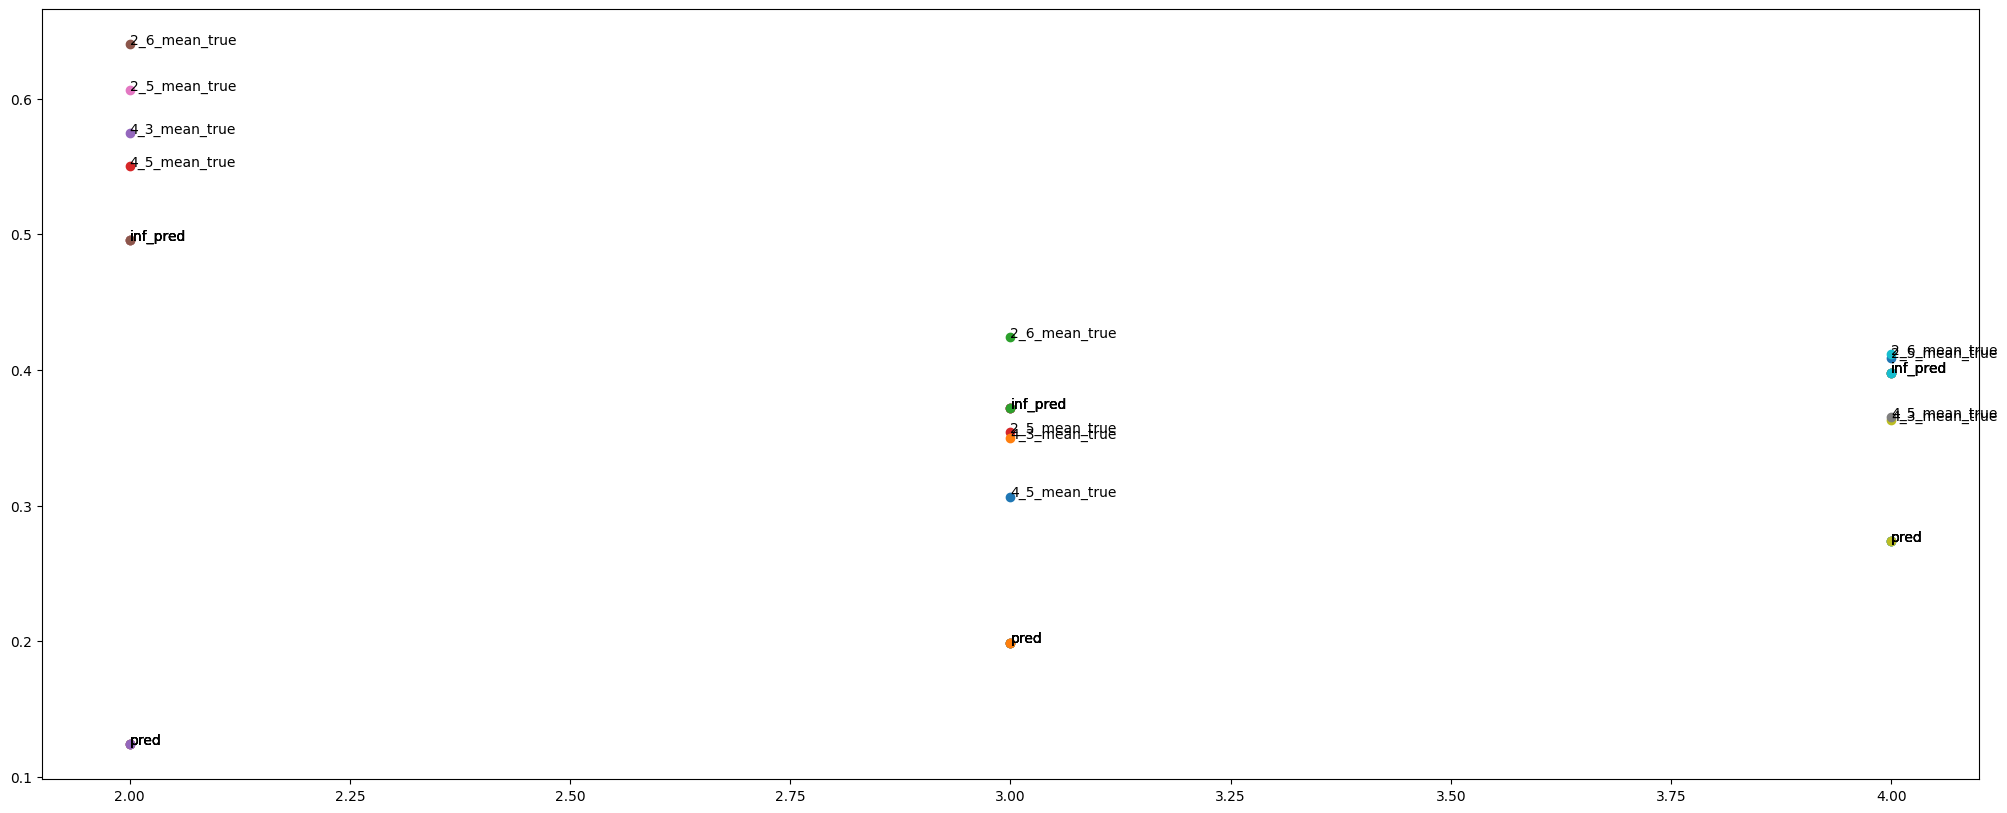

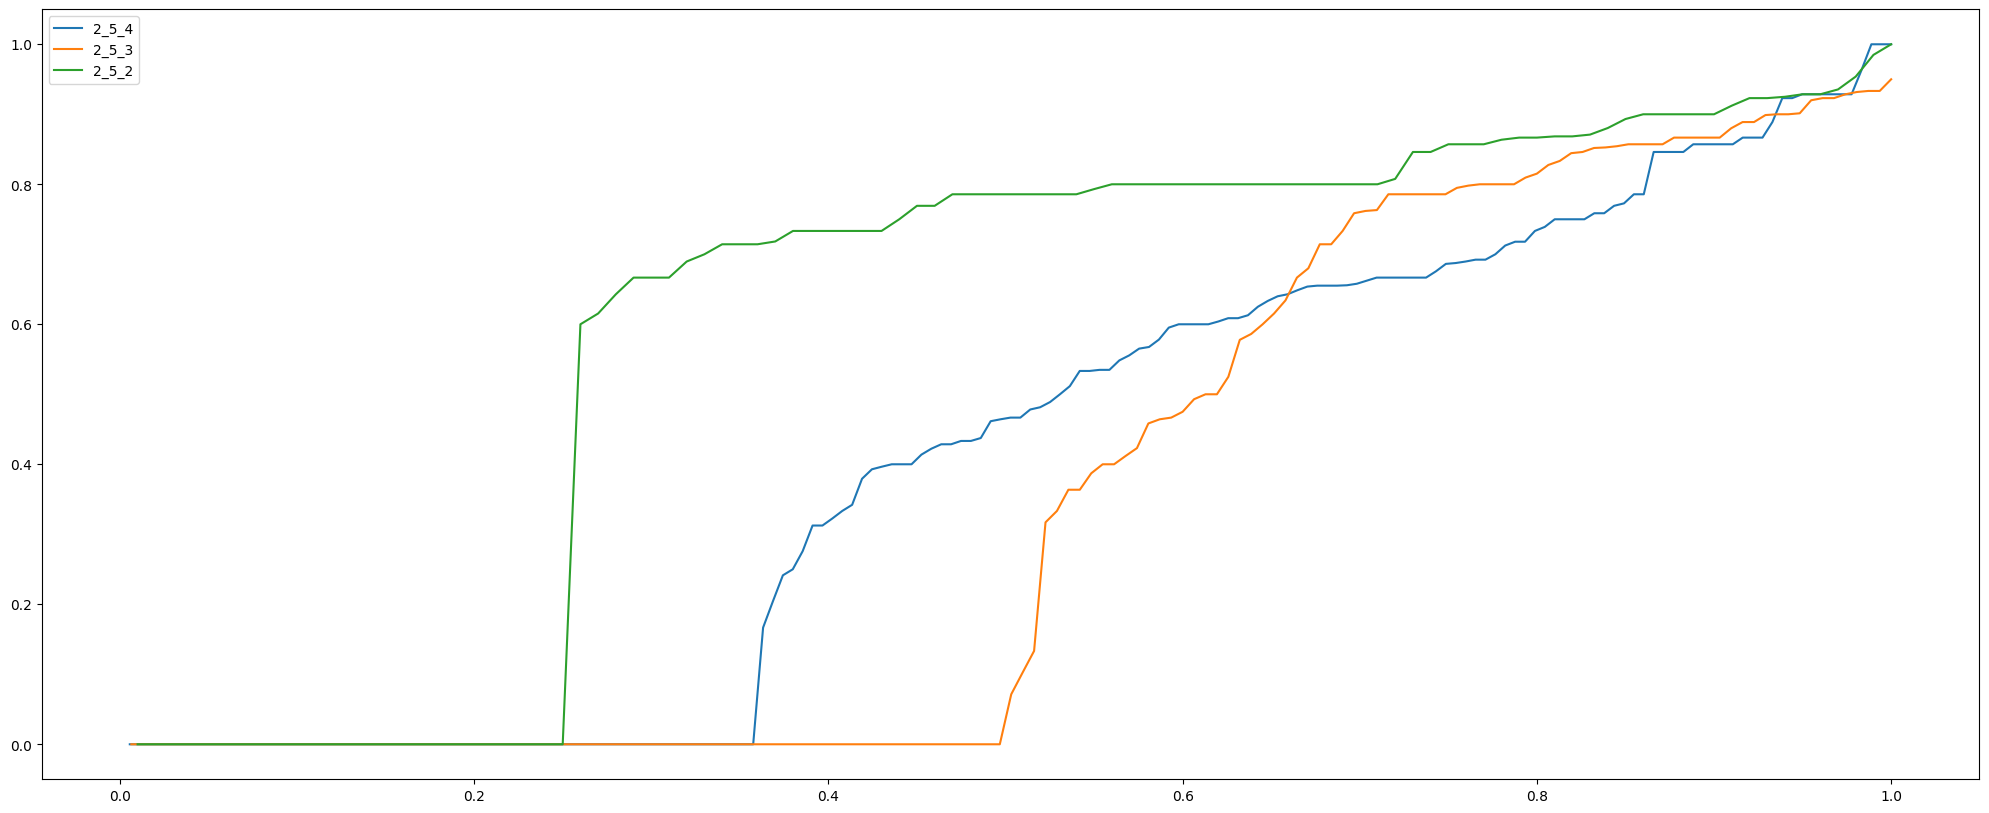

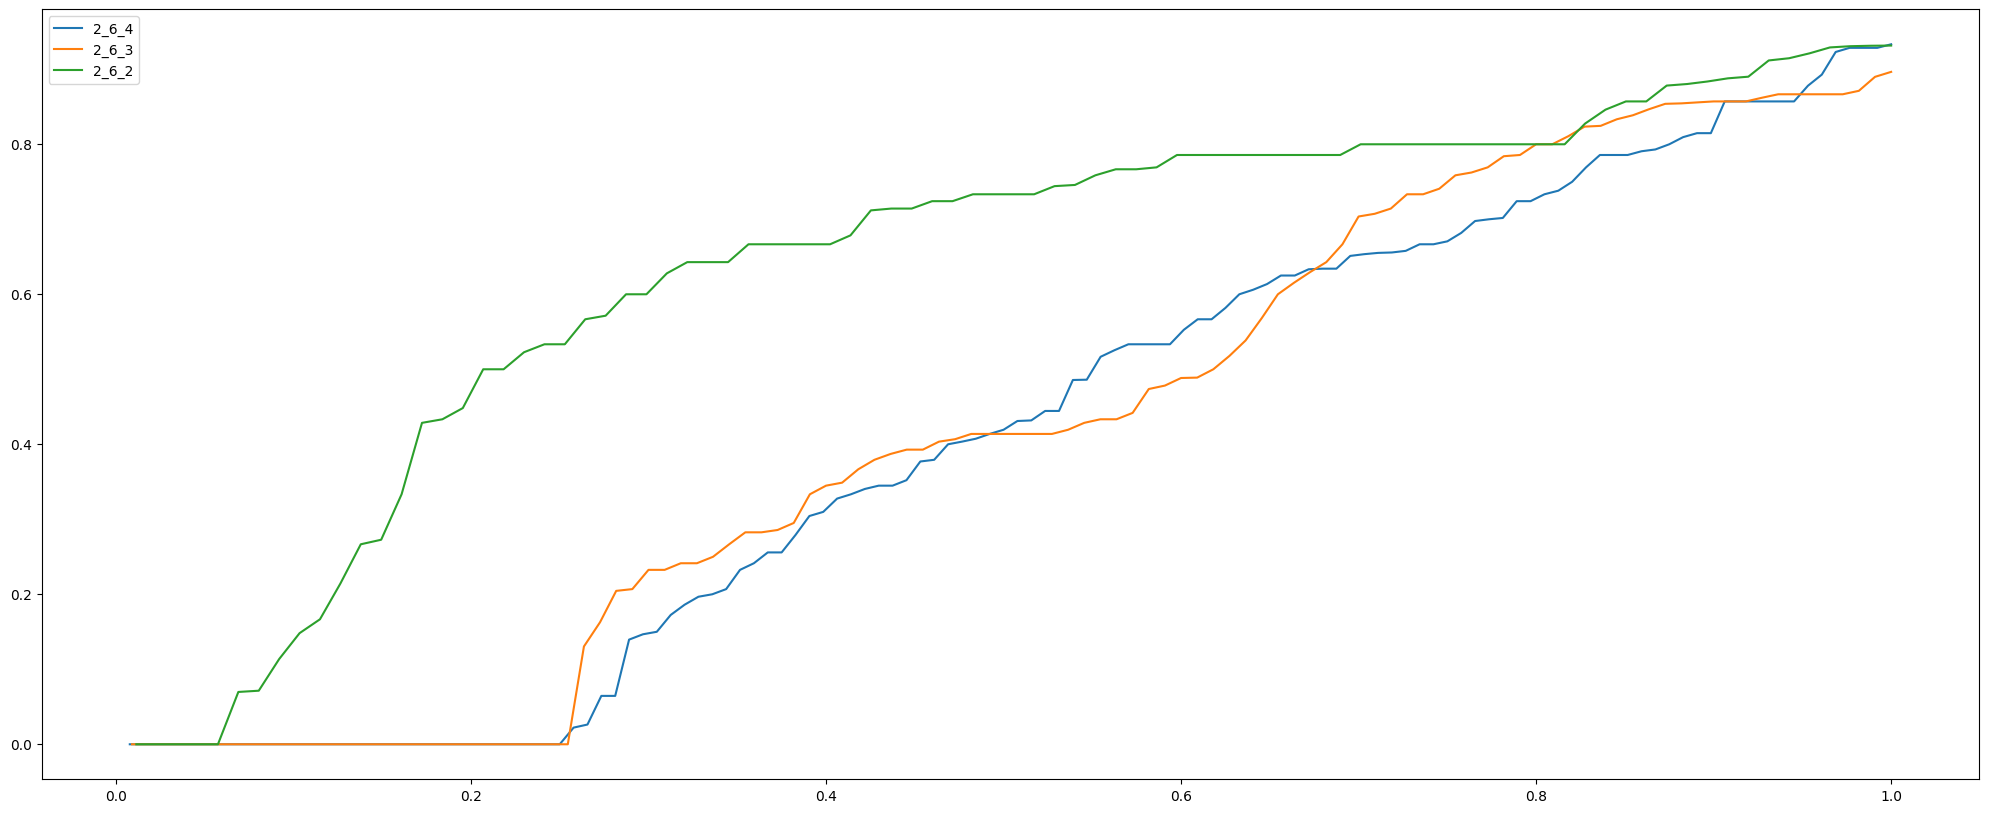

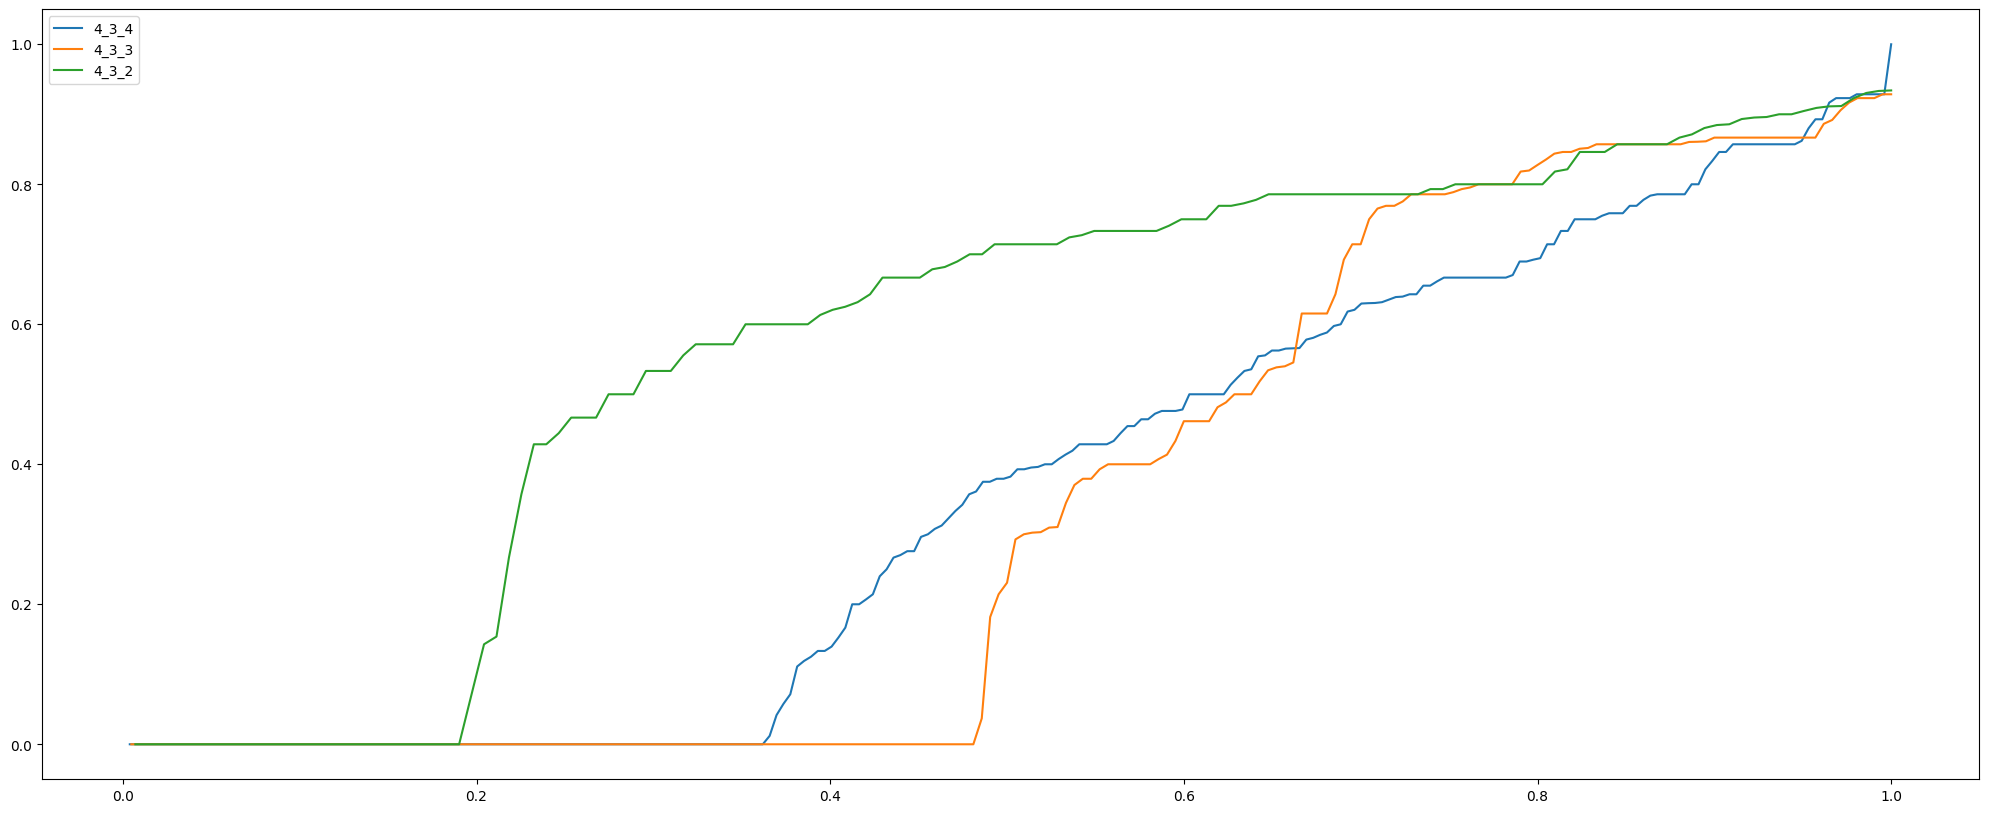

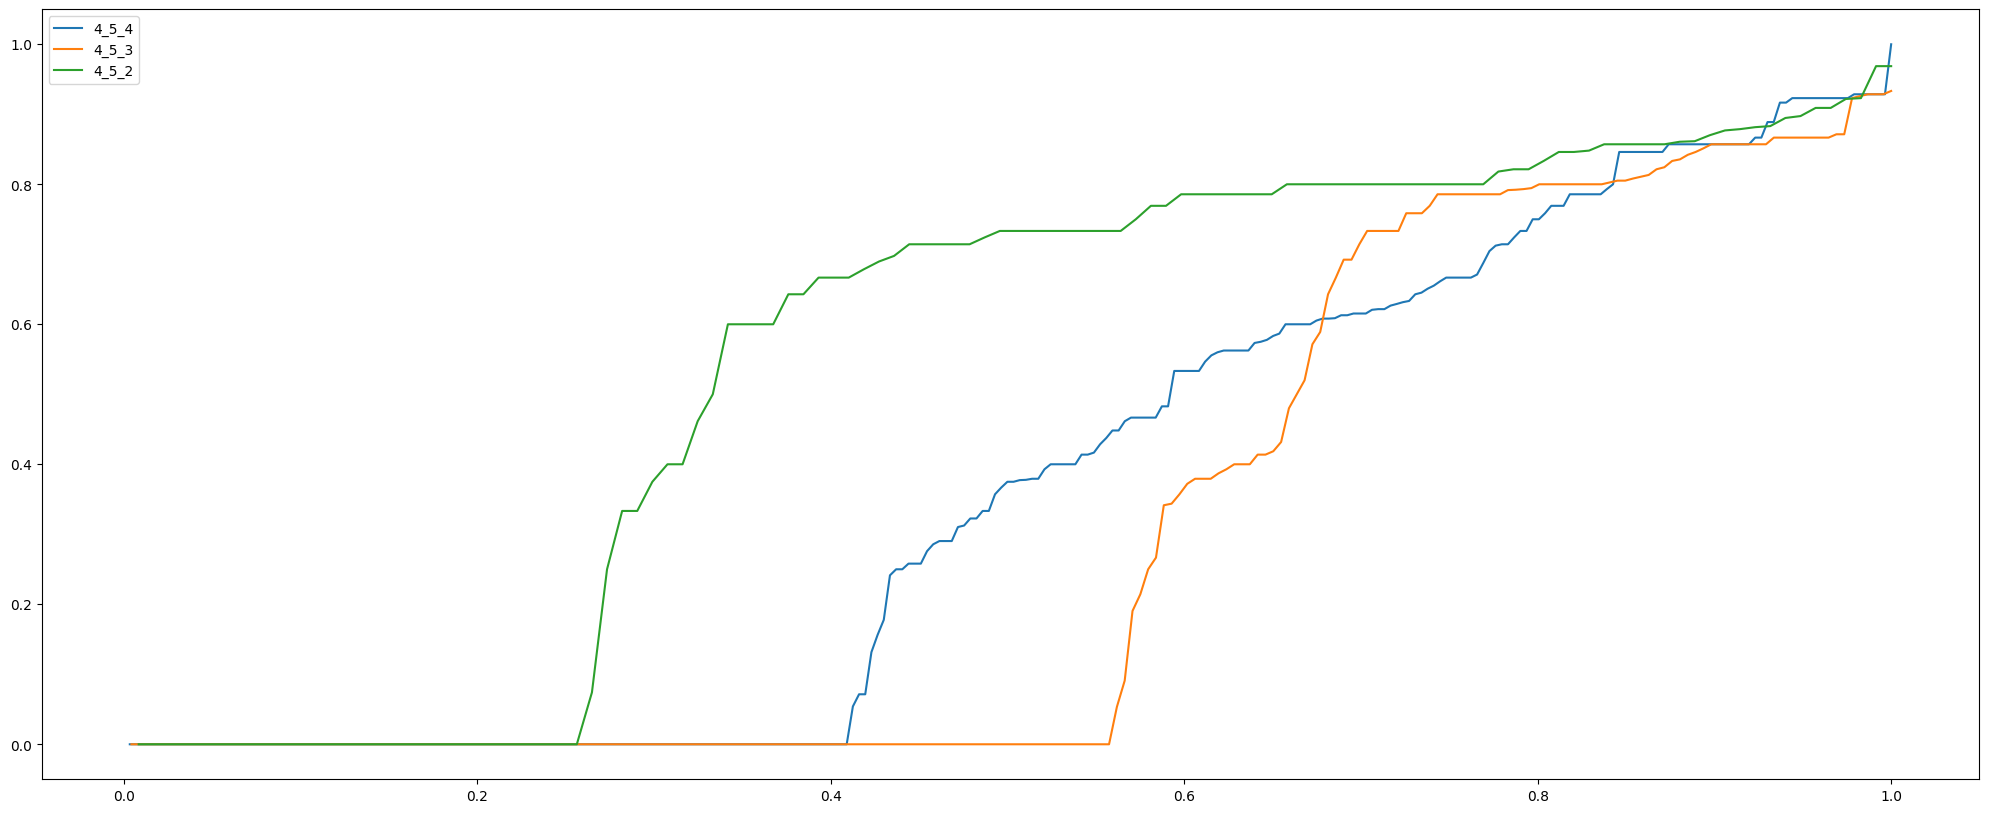

In [329]:


# print(world_size_5_count, world_size_5_fail_count)
# print(num_batch_size_10_count, num_batch_size_10_fail_count)
# print(batch_size_6_count, batch_size_6_fail_count)
# print(len(failure))
# print(total_counter-len(failure))

# print(throttle_map)
fig, axs = plt.subplots(figsize=(25,10))
true_y=[]
avg_true_y_map = {}
for t in throttle_map:
    # if throttle_map[t]["total"] > 30:
    #     # print(throttle_map[t]["total"])
    #     continue
    m1,m2,_ = t.split("+")
    # if m1=="4" and m2=="5":
    #     print(throttle_map[t])
    m2 = f"{m1}_{m2}"
    world = int(t.split("_")[2])
    num_batch = int(t.split("_")[4])
    
    if m2 not in avg_true_y_map:
        avg_true_y_map[m2] = {}
    if f"{world}_true" not in avg_true_y_map[m2]:
        avg_true_y_map[m2][f"{world}_true"] = []
        # avg_true_y_map[m2][f"{world}_worst_pred"] = []
        # avg_true_y_map[m2][f"{world}_max_pred"] = []
        # avg_true_y_map[m2][f"{world}_avg_pred"] = []
        avg_true_y_map[m2][f"{world}_pred"] = []
    
    
    
    avg_true_y_map[m2][f"{world}_true"].append(throttle_map[t]["throttled"]/throttle_map[t]["total"])
    # if m2=="4_5":
    #     print(throttle_map[t]["throttled"]/throttle_map[t]["total"])
    #     print(m2, avg_true_y_map[m2])
    #     print(avg_true_y_map)
    # y_agg = [tf_calc(w) for w in range(1, world)]
    # avg_true_y_map[m2][f"{world}_pred"].append(np.max(y_agg))#np.sum(y_agg)*(abs(num_batch-world)/(num_batch+world-1)))
    # avg_true_y_map[m2][f"{world}_pred"].append(np.max(y_agg)*(abs(num_batch-world)/(num_batch+world-1)))
    # avg_true_y_map[m2][f"{world}_pred"].append((abs(num_batch-world)/(num_batch+world-1))) #assume worst case throttle fraction of 1
    # avg_true_y_map[m2][f"{world}_worst_pred"].append((abs(num_batch)/(num_batch+world-1))) #assume worst case throttle fraction of 1
    # avg_true_y_map[m2][f"{world}_max_pred"].append((abs(num_batch-world)/(num_batch+world-1))) #assume worst case throttle fraction of 1
    # avg_true_y_map[m2][f"{world}_avg_pred"].append((abs(num_batch-world)/(num_batch+world-1))) #assume worst case throttle fraction of 1
    avg_true_y_map[m2][f"{world}_pred"]=num_batch 

# old_m2 = 
# for t in throttle_map:
#     main = int(t.split("_")[1])
#     world = int(t.split("_")[2])
#     num_batch = int(t.split("_")[4])
#     # world = int(t.split("_")[4])
    
#     print(t, throttle_map[t])
#     m1,m2,_ = t.split("+")
#     if (len(true_y)!=0) and (m2!=old_m2 or world!=old_world):#(m2!=old_m2 or main!=old_main or world!=old_world):
#         # print("here?")
#         y=[tf_calc(w) for w in range(1,old_world)]
#         # worst_y = sum(y) + max(y)*(num_batch-len(y))
#         worst_y = np.mean(y)#*(num_batch-len(y))
#         axs.scatter(old_world, worst_y)
#         # axs.scatter(old_world, max(true_y))
#         if m2 not in avg_true_y_map:
#             avg_true_y_map[m2] = {}
#         if old_world not in avg_true_y_map[m2]:
#             avg_true_y_map[m2][old_world]=[]
#         # avg_true_y_map[m2][old_world].append(max(true_y))
#         avg_true_y_map[m2][old_world].extend(true_y)
#         # axs.text(old_world, max(true_y), f"{old_m2}_max_true")
#         axs.text(old_world, worst_y, f"{old_m2}_worst")
#         true_y=[]
#     old_m2 = m2
#     old_main=main
#     old_world=world
#     true_y.append(throttle_map[t]["throttled"]/throttle_map[t]["total"])
#     # m2 = m2.split("main")[0]
#     # print(m1,m2, worst_y, true_y, true_y/worst_y)
#     # axs.scatter(world, worst_y)
#     # axs.scatter(world, true_y)
#     # axs.text(world, true_y, f"{m2}_true")
#     # axs.text(world, worst_y, f"{m2}_worst")


for m2 in avg_true_y_map:
    fig, cdf_axs = plt.subplots(figsize=(25,10))
    for world in avg_true_y_map[m2]:
        w=int(world.split("_")[0])
        if "true" in world:
            # if m2=="2_5":
            #     avg_true_y_map[m2][world] = sorted(avg_true_y_map[m2][world])
            #     avg_true_y_map[m2][world] = avg_true_y_map[m2][world][:-10]
            x, y = cdf_gen(avg_true_y_map[m2][world])
            cdf_axs.plot(y,x, label=f"{m2}_{w}")
            axs.scatter(w, np.mean(avg_true_y_map[m2][world]))
            # axs.scatter(w, np.max(avg_true_y_map[m2][world]))
            axs.text(w, np.mean(avg_true_y_map[m2][world]), f"{m2}_mean_true")
            # axs.text(w, np.max(avg_true_y_map[m2][world]), f"{m2}_max_true")

        if "pred" in world:

            y_agg = [tf_calc(y) for y in range(1,w)]
            num_batch = avg_true_y_map[m2][world]
            y_worst = (abs(num_batch)/(num_batch+w-1)) #always throttles maximally (tf=1)
            y_max = (abs(num_batch-w)/(num_batch+w-1)) #throttles maximally (tf=1) only for overlaps
            y = max(y_agg) #the maximum overlap possible
            # if w==2:
            inflated_y = np.min(y_agg)*abs(num_batch-w) if w!=4 else y_agg[-2]*abs(num_batch-w)
                # if w==2 else y_agg[-1]+y_agg[0]
            # if w==3:
            #     inflated_y = 

            # axs.scatter(w, np.mean(y_agg))
            # axs.text(w, np.mean(y_agg), f"mean_pred")

            # # axs.scatter(w, y_worst)
            # # axs.text(w, y_worst, f"worst_pred")

            # axs.scatter(w, y_max)
            # axs.text(w, y_max, f"max_pred")

            axs.scatter(w, y)
            axs.text(w, y, f"pred")
            axs.scatter(w, inflated_y)
            axs.text(w, inflated_y, f"inf_pred")
            # print(f"{m2}, {world}, fraction:{np.mean(avg_true_y_map[m2][f'{w}_true'])/inflated_y}")
            # print(f"{m2}, {world}, min_fraction:{np.mean(avg_true_y_map[m2][f'{w}_true'])/np.min(y_agg)}")
        #     print(f"{m2}, {world}, fraction:{  np.mean(avg_true_y_map[m2][f'{w}_pred'])/np.median(avg_true_y_map[m2][f'{w}_true'])}")
    cdf_axs.legend()
    

#  = (x < 8)[0.157 − 0.004 avail devs + 0.075x]+
# (x ≥ 8)[0.667 − 0.008 avail devs + 0.023x


# time_reader("../logs/sweep/b-1-2/1_ranking_logs/13_2_6_10_logs/speed_chronosbramble-1-2-13.log")